# Imports

In [1422]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1423]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools import add_constant
import plotly.graph_objects as go
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime
from dateutil.relativedelta import relativedelta
import itertools

# Constants

## Control

In [1424]:
FETCH_DATA = False
SAVE_RESULT = True
PLOT_RESULT = False
PLOT_SPREAD = False

## Dataset

In [ ]:
START_DATE = "2024-12-01"
END_DATE = "2025-12-01"

TOP_50 = ["BTC", "ETH", "BNB", "XRP", "SOL", "TRX", "DOGE", "ADA", "BCH", "LINK", "RAIN", "XMR", "XLM", "ZEC", "LEO", "LTC", "DAI", "SUI", "AVAX", "HBAR", "SHIB", "NIGHT", "STETH", "CRO", "UNI", "DOT", "AAVE", "CC", "BGB", "ASTER", "PI", "ENA", "SKY", "KCS", "WLD", "ONDO", "KAS", "APT", "ARB", "ALGO", "FLR", "ATOM", "FIL", "QNT", "VET", "M", "CBBTC", "WBT", "JUP", "LIT"]

## Routes

In [1426]:
TICKERS_DIR = "tickers"
PLOTS_DIR = "plots"

# Configuration

In [1427]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Functions

In [1428]:
def fetch_from_yfinance(ticker: str, route: str, start_date, end_date, fetch: bool=True):
    if fetch:
        s = ticker.upper().strip()
        yahoo_format = s if s.endswith("-USD") else f"{s}-USD"
        
        df1 = yf.download(
            tickers=yahoo_format,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        df2 = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        
        if len(df1) > 0:
            df = df1
        if len(df2) > 0:
            df = df2
            
        df.to_csv(route)
        df = pd.read_csv(route, skiprows=[1, 2], header=0)
        df = df.rename(columns={'Price': 'Date'})
        df = df.set_index('Date')
        df.to_csv(route)
    else:
        df = pd.read_csv(route)
    return df

In [1429]:
def adf_test(ticker, df, column='Close'):
    if df is None or df.empty or column not in df.columns:
        return {"Ticker": ticker, "Error": "Missing Data"}

    series = df[column].dropna()
    
    if len(series) < 20:
        return {"Ticker": ticker, "Error": f"Insufficient data points: {len(series)}"}

    result = adfuller(series, autolag='AIC')
    
    adf_output = {
        "Ticker": ticker,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Stationary": result[1] < 0.05,
        "Lags Used": result[2],
        "Observations": result[3]
    }
    
    return adf_output

In [1430]:
def hurst_exponent(series, q=2.0, max_lag=None, min_lag=2):
    series = np.asarray(series, dtype=float)
    n = len(series)

    if max_lag is None:
        max_lag = n // 4
    if max_lag <= min_lag:
        raise ValueError("max_lag must be > min_lag")

    # Lags
    lags = np.arange(min_lag, max_lag)

    # K_q values for each lag
    K = np.zeros_like(lags, dtype=float)

    for i, lag in enumerate(lags):
        diffs = np.abs(series[lag:] - series[:-lag])
        K[i] = np.mean(diffs ** q)

    # Fit log–log to estimate slope
    log_lags = np.log(lags)
    log_K = np.log(K)

    slope, _ = np.polyfit(log_lags, log_K, 1)

    Hurst = slope / q
    
    return Hurst

In [1431]:
def half_life(series):
    series = series.dropna()
    
    if len(series) < 10:
        print("For half-life series must be longer than 10 values")
        return np.nan
    
    # Create lagged series
    price_lag = series.shift(1)
    price_diff = series - price_lag
    
    # Remove NaN values
    valid_data = pd.concat([price_lag, price_diff], axis=1).dropna()
    X = add_constant(valid_data.iloc[:, 0])
    y = valid_data.iloc[:, 1]
    
    # Perform OLS regression
    try:
        model = OLS(y, X)
        results = model.fit()
        
        beta = results.params.iloc[1]
        
        half_life = -np.log(2) / np.log(1 + beta) if (1 + beta) > 0 else np.nan
        
        return half_life
    except Exception as e:
        print(f"Error occured while calculating half life: ${e}")
        return np.nan

In [1432]:
def store_series_plot(df, ticker: str, route: str = PLOTS_DIR):
    if not os.path.exists(route):
        os.makedirs(route)
        
    x_axis = df['Date'] if 'Date' in df.columns else df.index
        
    fig = go.Figure(data=[go.Candlestick(
        x=x_axis,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
    )])

    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=900,
        width=1600,
        showlegend=False
    )
    
    save_path = os.path.join(route, f"{ticker}.png")
    fig.write_image(save_path)

In [1433]:
def johansen_test(df_combined, det_order=0, k_ar_diff=1):
    df_clean = df_combined.dropna()
    
    if df_clean.shape[1] < 2:
        print("Need at least 2 series for Johansen test.")
        return None

    result = coint_johansen(df_clean, det_order, k_ar_diff)
    
    traces = result.lr1
    cvts = result.cvt
    eigenvalues = result.eig
    
    summary = []
    for i in range(len(traces)):
        is_cointegrated = traces[i] > cvts[i, 1]
        summary.append({
            "Rank": i + 1,
            "Trace Stat": round(traces[i], 4),
            "CV 95%": round(cvts[i, 1], 4),
            "Significant": is_cointegrated
        })
    
    return pd.DataFrame(summary), result.evec[:, 0]

# Fetch data

## Fetch merket data of top 50 crypto

In [ ]:
dfs = {}
if not os.path.exists(TICKERS_DIR):
    os.makedirs(TICKERS_DIR)
    print(f"Created directory: {TICKERS_DIR}")
for ticker in TOP_50:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
        df_full.index = pd.to_datetime(df_full.index)
        dfs[ticker] = df_full.loc[START_DATE : END_DATE].copy()
        if PLOT_RESULT:
            store_series_plot(dfs[ticker], ticker)
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

# Calculate parameters

In [ ]:
summary_results = []

for ticker in TOP_50:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
        df_full.index = pd.to_datetime(df_full.index)
        df = df_full.loc[START_DATE : END_DATE].copy()
        res = adf_test(ticker, df)
        res['hurst'] = hurst_exponent(df['Close'])
        res['half_life'] = half_life(df['Close'])
        summary_results.append(res)
        
    except Exception as e:
        print(f"Failed {ticker}: {e}")

Failed XRP: max_lag must be > min_lag


In [1437]:
summary_df = pd.DataFrame(summary_results)
summary_df.head()

,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
0,BTC,-1.76,0.40,False,0,248,0.45,26.13
1,ETH,-1.21,0.67,False,1,247,0.61,47.29
2,BNB,-1.03,0.74,False,8,356,0.47,64.48
3,SOL,-2.11,0.24,False,1,247,0.49,14.62
4,TRX,-0.17,0.94,False,12,236,0.54,1693.14


## Filter tickers with p-value $\le$ 0.05

In [1438]:
stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
stationary_df = stationary_df.sort_values(by='p-value')
print("Stationary tickers:", len(stationary_df))
stationary_df

Stationary tickers: 10


,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
15,DAI,-5.85,0.00,True,3,361,0.02,0.70
24,DOT,-4.64,0.00,True,6,358,0.46,33.12
16,SUI,-4.50,0.00,True,0,248,0.20,4.16
14,LTC,-4.20,0.00,True,0,248,0.14,5.70
12,ZEC,-3.74,0.00,True,13,351,0.56,2855.26
41,FIL,-3.74,0.00,True,4,360,0.45,32.89
20,NIGHT,-3.60,0.01,True,16,299,0.45,30.99
33,WLD,-3.32,0.01,True,2,362,0.48,24.15
11,XLM,-3.15,0.02,True,0,364,0.41,18.64
19,SHIB,-3.06,0.03,True,2,362,0.50,24.64


In [1439]:
# half_life_df = stationary_df.sort_values(by='half_life')
# half_life_df

# Mix dfs

In [1440]:
found_combinations = []
non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()

for r in [4, 5]:
    if len(found_combinations) >= 10: break
    
    potential_groups = list(itertools.combinations(non_stationary_tickers[:20], r)) 

    for group in potential_groups:
        if len(found_combinations) >= 10: break
        
        combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
        
        res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
        
        if res.lr1[0] > res.cvt[0, 1]: 
            weights = res.evec[:, 0] 
            found_combinations.append({
                'group': group,
                'weights': weights,
                'johansen_stat': res.lr1[0]
            })

In [ ]:
results_with_hl = []

for item in found_combinations:
    group = item['group']
    weights = item['weights']
    
    # Calculate the Spread series
    spread_series = pd.Series(0, index=dfs[group[0]].index)
    for i, ticker in enumerate(group):
        spread_series += dfs[ticker]['Close'] * weights[i]
    
    # Calculate Half-Life using your previously defined function
    hl = half_life(spread_series)
    
    results_with_hl.append({
        'group': group,
        'half_life': hl,
        'spread_series': spread_series,
        'weights': weights
    })

# Sort by half-life and pick the top 5
top_5_combinations = sorted(results_with_hl, key=lambda x: x['half_life'])[:5]

(array([ 0.40214678, -0.28033874,  0.03350074,  0.34029107]),
 np.float64(3.543142332228816))

In [1442]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    # Close and Open are straightforward linear combinations
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    # For High and Low, we must check the sign of the weight
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            # If weight is negative, the asset's 'Low' contributes to the spread's 'High'
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low
    
    # Store the result
    ticker_name = f"Spread_{'_'.join(group)}"
    store_series_plot(spread_df, ticker_name, folder)

In [1443]:
import plotly.graph_objects as go
import os

def plot_overlay_normalized_candlesticks(group, dfs, ticker_name, folder="plots"):
    """
    Plots multiple normalized candlestick series on a single shared axis.
    """
    fig = go.Figure()

    # Distinct color pairs for up/down candles per ticker
    color_pairs = [
        {'inc': '#26a69a', 'dec': '#ef5350'}, # Teal / Red
        {'inc': '#2196f3', 'dec': '#f44336'}, # Blue / Bright Red
        {'inc': '#9c27b0', 'dec': '#e91e63'}, # Purple / Pink
        {'inc': '#ff9800', 'dec': '#795548'}, # Orange / Brown
        {'inc': '#4caf50', 'dec': '#ffeb3b'}  # Green / Yellow
    ]

    for i, ticker in enumerate(group):
        if ticker not in dfs:
            continue
            
        df = dfs[ticker].copy()
        
        # 1. Normalization: Divide all OHLC columns by the first Close price
        base_price = df['Close'].iloc[0]
        df_norm = df[['Open', 'High', 'Low', 'Close']] / base_price
        
        # 2. Select colors for this specific ticker
        colors = color_pairs[i % len(color_pairs)]
        
        # 3. Add the trace
        fig.add_trace(go.Candlestick(
            x=df.index,
            open=df_norm['Open'],
            high=df_norm['High'],
            low=df_norm['Low'],
            close=df_norm['Close'],
            name=f"{ticker} (Norm)",
            increasing_line_color=colors['inc'],
            decreasing_line_color=colors['dec'],
            increasing_fillcolor=colors['inc'],
            decreasing_fillcolor=colors['dec']
        ))

    # 4. Final Layout Adjustments
    fig.update_layout(
        title=f"Overlay Normalized Candlesticks: {', '.join(group)}",
        xaxis_title="Date",
        yaxis_title="Normalized Price (Base = 1.0)",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600,
        width=1000,
        # This helps see the different candles if they overlap heavily
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Overlay_Normalized_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Overlay plot saved to {save_path}")

In [1444]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    spread_df['Open'] = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low

    ticker_name = "_".join(group)
    fig = go.Figure(data=[go.Candlestick(
        x=spread_df.index,
        open=spread_df['Open'],
        high=spread_df['High'],
        low=spread_df['Low'],
        close=spread_df['Close'],
        increasing_line_color='#26a69a',
        decreasing_line_color='#ef5350' 
    )])

    fig.update_layout(
        title=f"Stationary Spread Candlestick (Group: {ticker_name})",
        xaxis_title="Date",
        yaxis_title="Spread Value",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Spread_Candle_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Spread candlestick saved to {save_path}")

In [1445]:
if PLOT_SPREAD:
    for comb in top_5_combinations:
        group = comb['group']
        weights = comb['weights']
        ticker_name = "_".join(group)
        
        plot_overlay_normalized_candlesticks(group, dfs, ticker_name)
        
        plot_spread_candlestick(group, weights, dfs)

# Strategy

In [1446]:
list(map(lambda comb: comb['group'], top_5_combinations))

[('BTC', 'ETH', 'BNB', 'RAIN'),
 ('BTC', 'ETH', 'BNB', 'SOL'),
 ('BTC', 'ETH', 'BNB', 'AAVE'),
 ('BTC', 'ETH', 'SOL', 'STETH'),
 ('BTC', 'ETH', 'BNB', 'LINK')]

In [1447]:
def calculate_strategy_params(spread_df, hl_value):
    lookback = int(hl_value * (int(np.ceil(30 / hl_value)) if hl_value < 30 else 2))
    
    ema_range = spread_df['Close'].ewm(span=lookback, adjust=False).mean()
    std_spread = spread_df['Close'].rolling(window=lookback, min_periods=10).std()
    
    return lookback, ema_range, std_spread

In [1448]:
strategy_results = []

for comb in top_5_combinations:
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method="pad") * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_strategy_params(spread_df, hl)
    
    spread_df['std'] = std
    # spread_df['std'] = spread_df['std'].fillna(0)
    spread_df['ema'] = ema
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    strategy_results.append({
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    })


Group: BTC-ETH-BNB-RAIN
Half-life: 3.54 days
Calculated Lookback: 31 days
Latest EMA (of Range): 33.4847
Latest STD: 0.6478

Group: BTC-ETH-BNB-SOL
Half-life: 4.16 days
Calculated Lookback: 33 days
Latest EMA (of Range): 21.7989
Latest STD: 0.9302

Group: BTC-ETH-BNB-AAVE
Half-life: 5.24 days
Calculated Lookback: 31 days
Latest EMA (of Range): 25.2697
Latest STD: 0.9786

Group: BTC-ETH-SOL-STETH
Half-life: 5.49 days
Calculated Lookback: 32 days
Latest EMA (of Range): 18.3218
Latest STD: 1.1045

Group: BTC-ETH-BNB-LINK
Half-life: 6.07 days
Calculated Lookback: 30 days
Latest EMA (of Range): 26.1326
Latest STD: 0.9649


C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or spec

('BTC', 'ETH', 'BNB', 'SOL')


,Close,Open,Return,High,Low,std,ema,position,strategy_return,portfolio,BNH
229,22.41,22.36,1.94,23.60,21.93,0.72,21.34,-2.00,-1.94,2119.79,1225.43
230,22.30,22.28,-0.46,22.87,21.57,0.74,21.40,-2.00,0.46,2129.56,1219.79
231,22.37,21.95,0.32,23.26,21.05,0.76,21.46,-2.00,-0.32,2122.82,1223.65
232,22.80,22.62,1.92,23.53,22.00,0.79,21.54,-2.00,-1.92,2082.15,1247.09
233,22.88,22.73,0.33,23.40,21.72,0.82,21.62,-2.00,-0.33,2075.31,1251.19
234,22.92,22.90,0.19,24.25,21.67,0.83,21.69,-2.00,-0.19,2071.37,1253.56
235,23.07,23.14,0.63,23.57,22.11,0.84,21.77,-2.00,-0.63,2058.29,1261.48
236,23.09,23.04,0.09,23.53,22.15,0.79,21.85,-2.00,-0.09,2056.41,1262.63
237,23.21,23.33,0.53,23.91,22.44,0.78,21.93,-2.00,-0.53,2045.44,1269.36
238,24.17,23.34,4.12,25.18,22.49,0.85,22.06,-2.00,-4.12,1961.18,1321.66


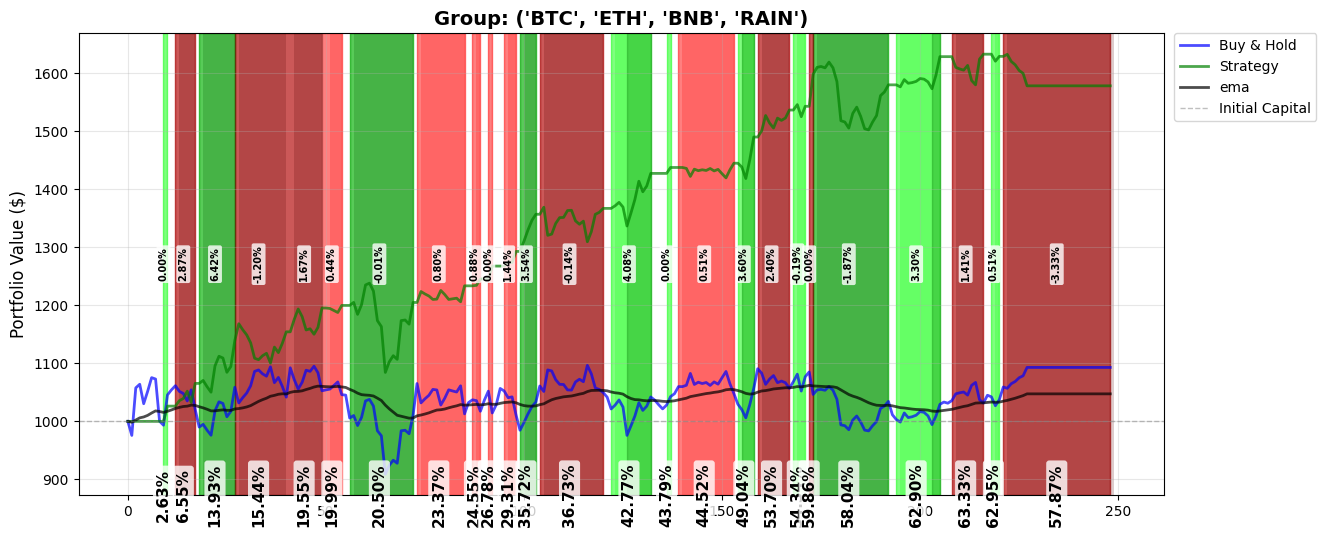

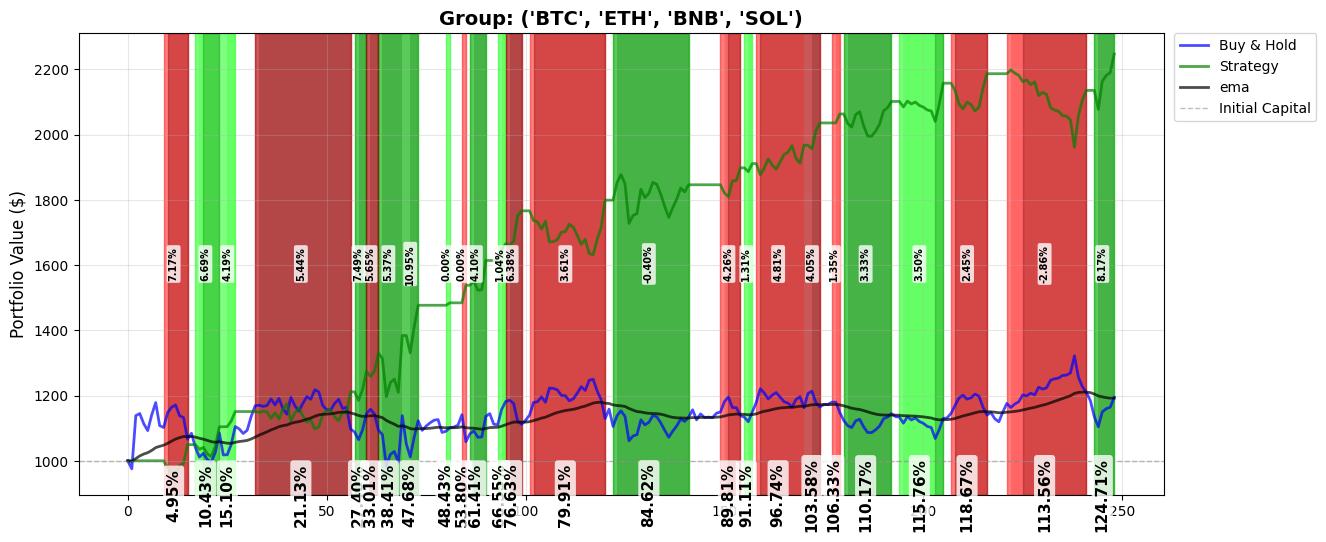

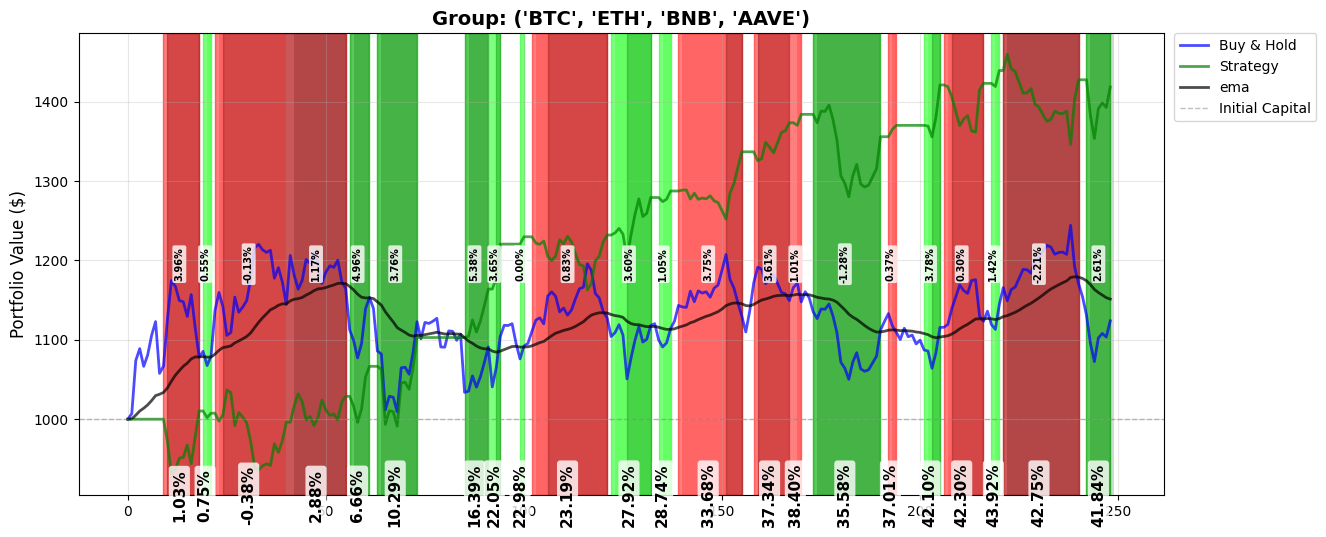

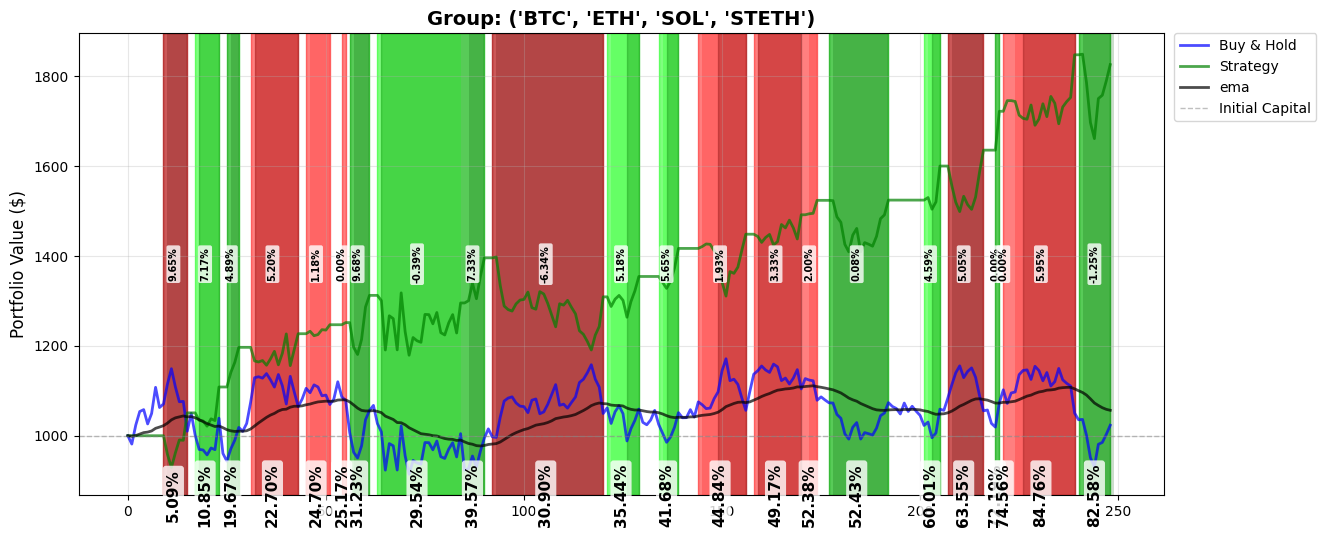

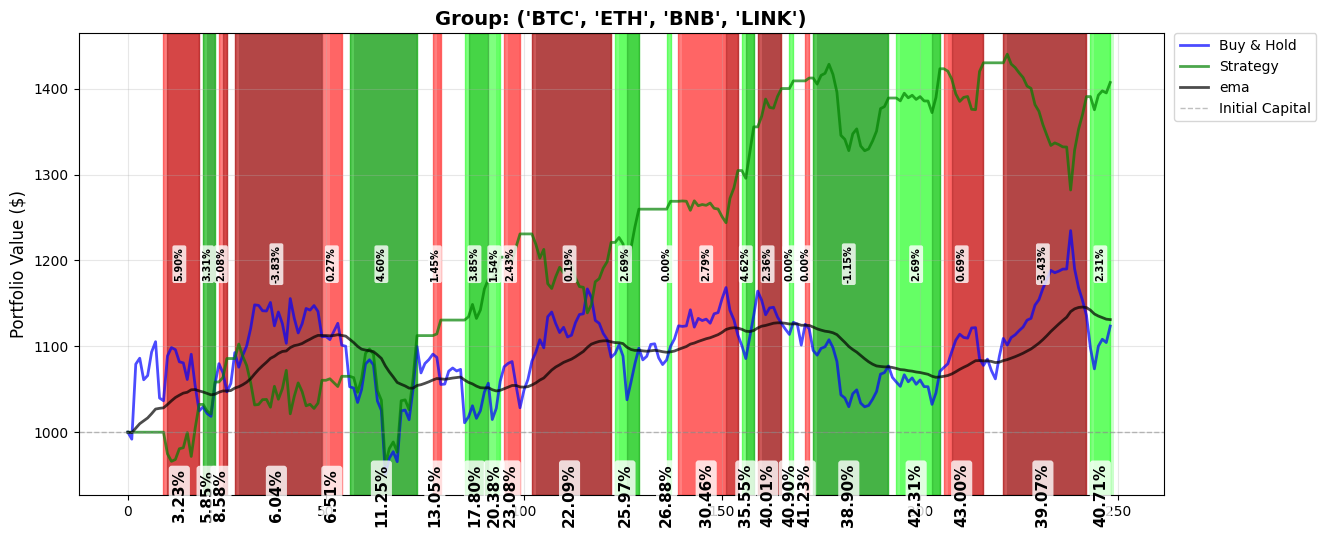

In [1449]:
for result in strategy_results:
    # print(result['spread_df'])
    df = result['spread_df']
    result['spread_df']['short_signal1'] = np.where(df['High'] > df['ema'] + df['std'], 1, 0)
    result['spread_df']['short_signal2'] = np.where(df['High'] > df['ema'] + 2 * df['std'], 1, 0)
    
    result['spread_df']['long_signal1'] = np.where(df['Low'] < df['ema'] - df['std'], 1, 0)
    result['spread_df']['long_signal2'] = np.where(df['Low'] < df['ema'] - 2 * df['std'], 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        if result['spread_df']['short_crossover2'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        if result['spread_df']['long_crossover2'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1:  
            if current_position > 0:
                current_position = 0
        elif result['spread_df']['ema_short_crossover'].iloc[i] == 1:  
            if current_position < 0:
                current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = 1000

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = 1000 * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = 1000
    
    
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
    # plt.plot(df.index, df['ema'], label='ema', linewidth=2, alpha=0.7, color='orange')
    plt.plot(df.index, df['ema'] * (1000 / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    # 2. Filter for active trades only (remove the '0'/flat periods)
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'] + 1, 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']
                
            
            # Calculate Return for THIS trade (End / Start)
            # This automatically respects the /2 logic because 'portfolio' already 
            # grew/shrank by the halved amount.
            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $1000 start)
            running_total_gain = (end_val / 1000 - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, 0, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

            # 5. Background Span
            c_map = {1.0: '#0F0', 2.0: '#050', -1.0: '#F00', -2.0: '#500'}
            color = c_map.get(trade['pos_type'], 'gray')
            
            ax.axvspan(trade['start_idx'] + 1, trade['end_idx'] + 1, 
                    color=color, alpha=0.2, linewidth=0)
    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 'trade_id']
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')

# trades  
x = strategy_results[1]
print(x['group'])
x['spread_df'].tail(20)

# Lookahead Bias

In [ ]:
def test_strategy(start_date = datetime(2025, 1, 1), end_date = None):
    if end_date == None:
        end_date = start_date + relativedelta(months=1)
    
    train_start_date = start_date - relativedelta(months=1)
    train_end_date = start_date - relativedelta(days=1)
    
    summary_results = []

    for ticker in TOP_50:
        filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
        try:
            df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
            df_full.index = pd.to_datetime(df_full.index)
            df = df_full.loc[train_start_date : train_end_date].copy()

            if df.empty:
                continue

            res = adf_test(ticker, df)
            res['hurst'] = hurst_exponent(df['Close'])
            res['half_life'] = half_life(df['Close'])
            res['df'] = df
            summary_results.append(res)

        except Exception as e:
            print(f"Failed {ticker}: {e}")

    summary_df = pd.DataFrame(summary_results)
    stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
    stationary_df = stationary_df.sort_values(by='p-value')
    found_combinations = []
    non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()
    
    ticker_to_df = {item['Ticker']: item['df'] for item in summary_results}

    # --------------------------------------------------------------------------
    for r in [4, 5]:
        if len(found_combinations) >= 10: break
        
        potential_groups = list(itertools.combinations(non_stationary_tickers[:20], r)) 

        for group in potential_groups:
            if len(found_combinations) >= 10: break
            
            combined_data = pd.concat([ticker_to_df[t]['Close'] for t in group], axis=1).dropna()
            
            res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
            
            if res.lr1[0] > res.cvt[0, 1]: 
                weights = res.evec[:, 0] 
                found_combinations.append({
                    'group': group,
                    'weights': weights,
                    'johansen_stat': res.lr1[0]
                })
                
    # -------------------------------------------------------------------------------------
    results_with_hl = []
    for item in found_combinations:
        group = item['group']
        weights = item['weights']
        
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
        
        hl = half_life(spread_series)
        
        results_with_hl.append({
            'group': group,
            'half_life': hl,
            'spread_series': spread_series,
            'weights': weights
        })

    # ------------------------------------------------------------------------
    comb = sorted(results_with_hl, key=lambda x: x['half_life'])[0]
    
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method="pad") * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_strategy_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    # ------------------------------------------------------
    
    result = {
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    }
    
    df = result['spread_df']
    result['spread_df']['short_signal1'] = np.where(df['High'] > df['ema'] + df['std'], 1, 0)
    result['spread_df']['short_signal2'] = np.where(df['High'] > df['ema'] + 2 * df['std'], 1, 0)
    
    result['spread_df']['long_signal1'] = np.where(df['Low'] < df['ema'] - df['std'], 1, 0)
    result['spread_df']['long_signal2'] = np.where(df['Low'] < df['ema'] - 2 * df['std'], 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        if result['spread_df']['short_crossover2'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        if result['spread_df']['long_crossover2'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1:  
            if current_position > 0:
                current_position = 0
        elif result['spread_df']['ema_short_crossover'].iloc[i] == 1:  
            if current_position < 0:
                current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = 1000

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = 1000 * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = 1000
    
    # -------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
    # plt.plot(df.index, df['ema'], label='ema', linewidth=2, alpha=0.7, color='orange')
    plt.plot(df.index, df['ema'] * (1000 / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    # 2. Filter for active trades only (remove the '0'/flat periods)
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'] + 1, 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']
                
            
            # Calculate Return for THIS trade (End / Start)
            # This automatically respects the /2 logic because 'portfolio' already 
            # grew/shrank by the halved amount.
            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $1000 start)
            running_total_gain = (end_val / 1000 - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, 0, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

            # 5. Background Span
            c_map = {1.0: '#0F0', 2.0: '#050', -1.0: '#F00', -2.0: '#500'}
            color = c_map.get(trade['pos_type'], 'gray')
            
            ax.axvspan(trade['start_idx'] + 1, trade['end_idx'] + 1, 
                    color=color, alpha=0.2, linewidth=0)
    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 'trade_id']
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')

    return result